# Optimize growth rate calculation

This notebook allows you to compare different growth_rate calculation methods on your dataset

First, set the `PATH` to your dataset. If you do not want to optimize on the entire dataset, modify the `exp = FluidExperiment(PATH)` to only load selected positions or color channels

The routine will loop thorough all `METHODS` and calculate the growth rate with each of it

Then, rate plots will be produced for the growth rates calculated with each method seperately

you can further set parameters:
- `VALUE_COLUMN`: column to be measured with
- `INTEGRATION_WINDOW`: window within which the growth rate is determined
- `SMOOTH_WINDOW`: window within which the data is smoothed (prior to growth rate calculation)
- `from mutate.smooth import smooth_linear as SMOOTH_METHOD`: Smooth method to use: `smooth_linear` is the standard smooth method, see optimize_smoothing.ipynb for other methods

In [ ]:

from fluid_experiment.fluid_experiment import FluidExperiment
from analysis.growth_rate import growth_rate_polyfit, calculate_growth_rate_r2, calculate_growth_rate

from mutate.smooth import smooth_linear as SMOOTH_METHOD #select which smoothing you want to use
PATH = "../../data/midap-tools_example"
VALUE_COLUMN = "major_axis_length"
INTEGRATION_WINDOW = 5
SMOOTH_WINDOW = 9
METHODS =  [
    {"name": "STANDARD",
     "desciption": "simple average delta",
     "postfix": "_standard",
     "function": calculate_growth_rate,
     "kwargs": {}},
    {"name": "POLYFIT",
     "desciption": "using np.polyfit (1st order)",
     "postfix": "_polyfit",
     "function": growth_rate_polyfit,
     "kwargs": {},
    },
    {"name": "LINREG",
     "desciption": "linear regression model (warning, very slow)!",
     "postfix": "_linreg",
     "function": calculate_growth_rate_r2,
     "kwargs": {},
    }
]

exp = FluidExperiment(PATH)
exp.load_metadata_template()
print(exp)

exp.filter_data("frame", max_value=80)
exp.filter_data("trackID", min_occurences=5)
exp.calculate_transform_data(VALUE_COLUMN)
value_column_log = VALUE_COLUMN + "_log"
exp.smooth_data(SMOOTH_WINDOW,"trackID",value_column_log, custom_method= SMOOTH_METHOD)
value_column_log_smoothed = value_column_log + "_smoothed"



Loading sample at position pos1 for color channel YFP
Loading sample at position pos1 for color channel CFP
Loading sample at position pos2 for color channel YFP
Loading sample at position pos2 for color channel CFP
Loading sample at position pos3 for color channel YFP
Loading sample at position pos3 for color channel CFP
Loading sample at position pos4 for color channel YFP
Loading sample at position pos4 for color channel CFP
Loading sample at position pos5 for color channel YFP
Loading sample at position pos5 for color channel CFP
Loading sample at position pos6 for color channel YFP
Loading sample at position pos6 for color channel CFP
Successfully loaded data with consistent number of frames: 143
FluidExperiment with name: experiment
Path: ../../data/midap-tools_example
6 positions: pos1, pos2, pos3, pos4, pos5, pos6
2 color channels: YFP, CFP
length of experiment is consistent: 143
experiment has consistent headers: Unnamed: 0, globalID, frame, labelID, trackID, lineageID, trackI

# Calculate growth rate with different methods

In [10]:
import time

for m in METHODS:
    growth_rate_column = "growth_rate" + m["postfix"]
    name = m["name"]
    desc = m["desciption"]
    t = time.time()
    exp.calculate_growth_rate(integration_window=INTEGRATION_WINDOW,
                              id_column="trackID", 
                              growth_rate_column= growth_rate_column, 
                              value_column= value_column_log_smoothed, 
                              custom_method=m["function"])
    print(f"elapse time for {name}: {round(time.time() - t,2)} seconds")



Calculate growth_rate_standard for trackID measured with major_axis_length_log_smoothed over an integration window of 5
elapse time for STANDARD: 3.7 seconds
Calculate growth_rate_polyfit for trackID measured with major_axis_length_log_smoothed over an integration window of 5
elapse time for POLYFIT: 7.64 seconds
Calculate growth_rate_linreg for trackID measured with major_axis_length_log_smoothed over an integration window of 5
elapse time for LINREG: 103.28 seconds


# Visualize Results

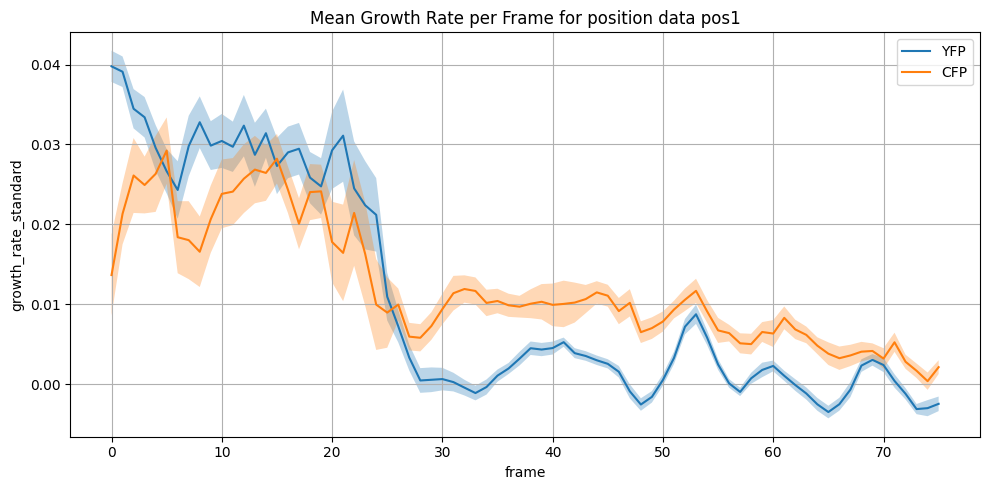

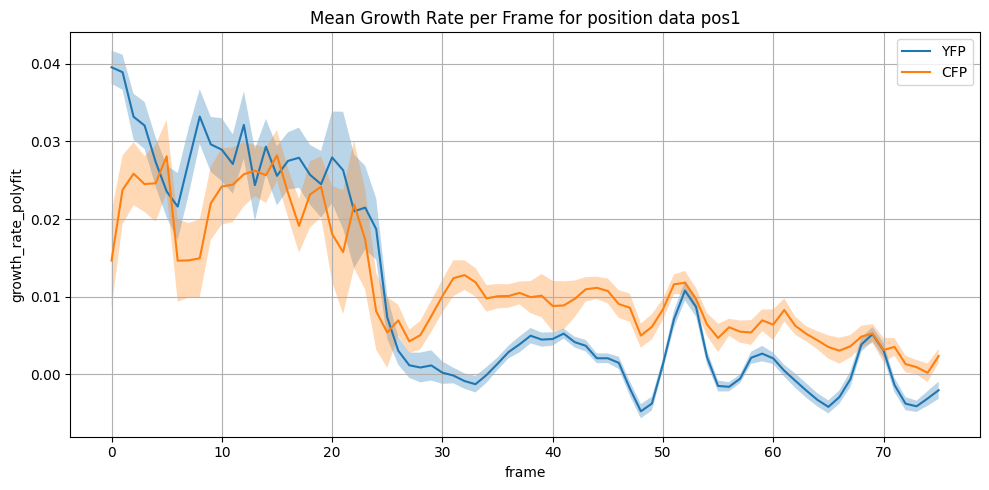

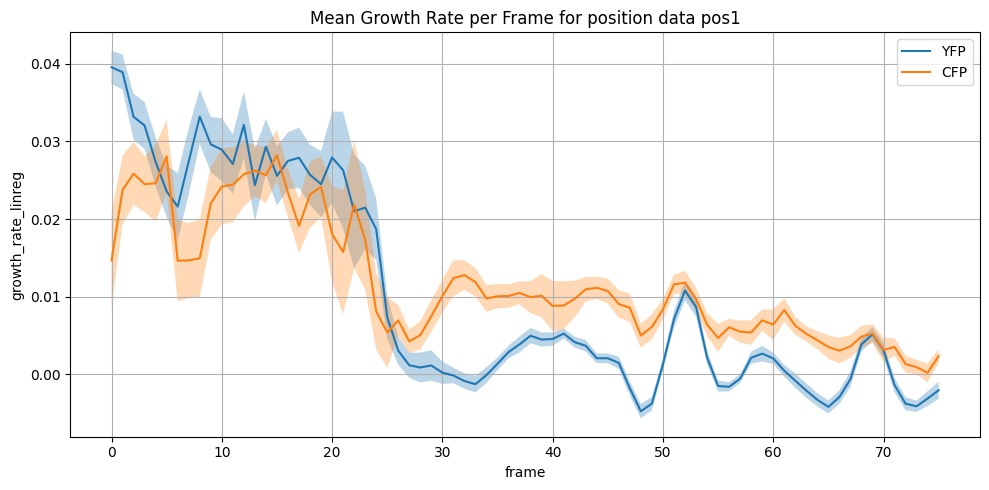

In [12]:
POSITIONS = ["pos1"]
COLOR_CHANNELS = ["YFP","CFP"]

for m in METHODS:
    growth_rate_column = "growth_rate" + m["postfix"]
    exp.plot_rates(positions= POSITIONS, rate_column=growth_rate_column, color_channels=COLOR_CHANNELS)

# Visualize results for different methods (grouped)

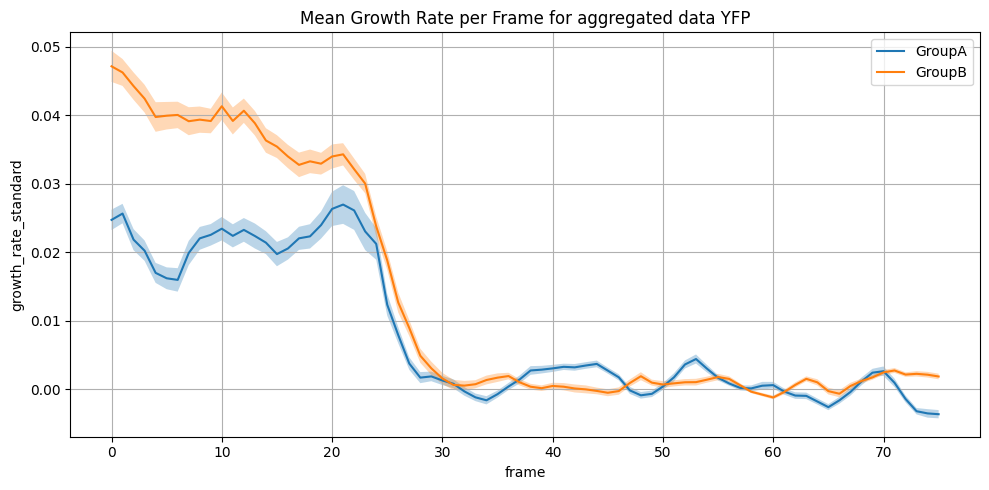

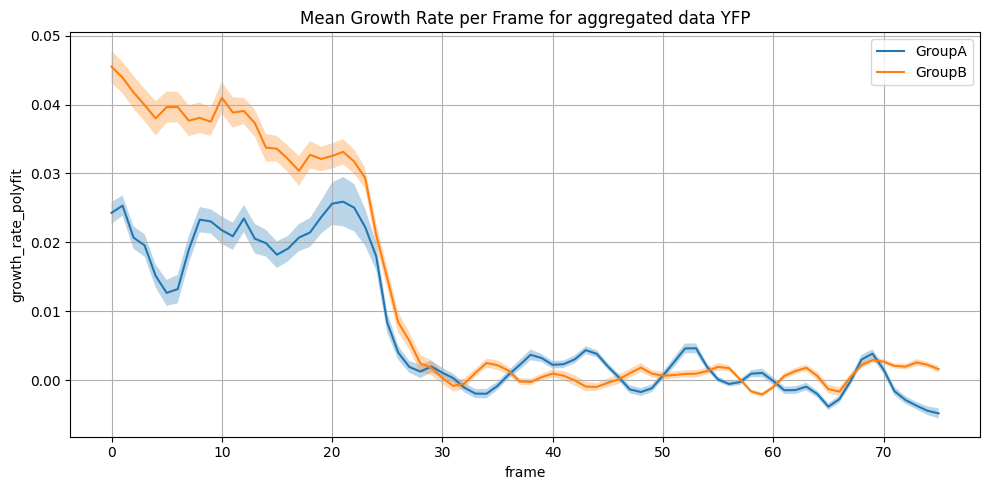

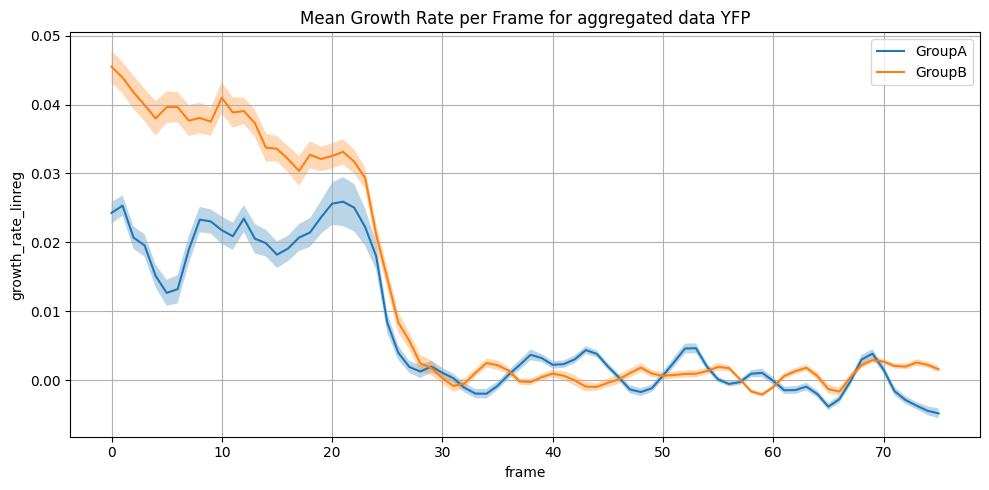

In [13]:
METADATA_GROUP = "group"
COLOR_CHANNELS = ["YFP"]

for m in METHODS:
    growth_rate_column = "growth_rate" + m["postfix"]
    exp.plot_rates(group_by= METADATA_GROUP, flip_grouping=True, rate_column=growth_rate_column, color_channels=COLOR_CHANNELS)